# Support Vector Machines from Scratch - Primal Soft-Margin with Subgradient Descent

This notebook implements a **linear soft-margin SVM** by minimising the primal objective directly via subgradient descent. The goal is to build intuition for the core optimisation problem before moving to the kernelised dual formulation in `project.ipynb`.

**Scope and limitations:**
- Linear kernel only (no feature transformation)
- Subgradient descent on individual samples (stochastic, not batched)
- No convergence guarantee — subgradient descent on a non-smooth objective oscillates near the optimum rather than converging exactly
- The sklearn `SVC` uses SMO on the dual formulation, which is strictly more correct and produces the true maximum-margin solution

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

In [2]:
# Generate synthetic dataset
X, y = make_blobs(n_samples=100, centers=2, cluster_std=0.8, random_state=42)

In [3]:
X.shape, y.shape

((100, 2), (100,))

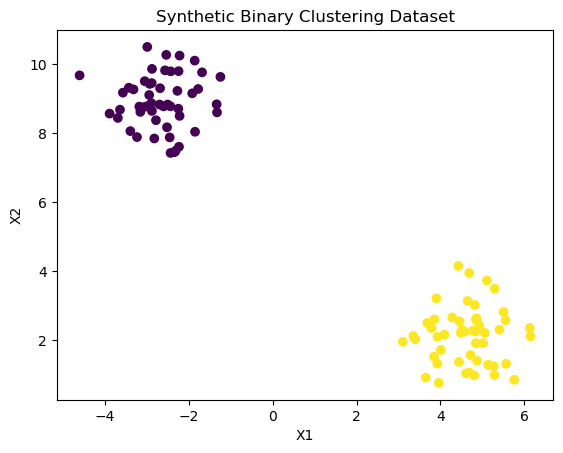

In [4]:
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Binary Clustering Dataset")
plt.show()

In [5]:
# Labels encoding
y = np.where(y == 0, -1, 1)  # Convert labels from {0, 1} to {-1, 1}

## Primal Objective and Update Rules

The soft-margin SVM solves:

$$\min_{\mathbf{w}, b} \quad \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \max\left(0,\, 1 - y_i(\mathbf{w}^\top \mathbf{x}_i + b)\right)$$

The first term maximises the margin (minimising $\|\mathbf{w}\|$ is equivalent to
maximising $\frac{2}{\|\mathbf{w}\|}$). The second term penalises margin violations
via the hinge loss. $C$ controls the trade-off between the two.

**Subgradient update rules** for a single sample $(\mathbf{x}_i, y_i)$:

- If $y_i(\mathbf{w}^\top \mathbf{x}_i + b) < 1$ (margin violation):

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \left(\mathbf{w} - C y_i \mathbf{x}_i\right)$$
$$b \leftarrow b + \eta \, C \, y_i$$

- If $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1$ (correctly classified, outside margin):

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \, \mathbf{w}$$
$$b \leftarrow b \quad \text{(no update)}$$

Labels are encoded as $y_i \in \{-1, +1\}$, this encoding is required for the
margin constraint $y_i f_i \geq 1$ to be sign-correct for both classes.

In [6]:
# Initialize model parameters
w = np.zeros(X.shape[1])  # Weights
b = 0  # Bias
learning_rate = 0.0001
C = 1.0  # Regularization parameter
n_epochs = 5000

In [7]:
# Soft-Margin SVM Training Loop (see theory.md section 3 for details)
for epoch in range(n_epochs):
    for i in range(X.shape[0]):
        # Calculate the decision value
        decision_value = np.dot(w, X[i]) + b
        
        # Check if the point is correctly classified
        if y[i] * decision_value < 1:  # Margin violation
            # Update weights and bias
            w -= learning_rate * (w + C * (-y[i] * X[i]))
            b += learning_rate * y[i] * C
        else:
            # Only apply regularization to weights
            w -= learning_rate * w

In [8]:
print("Trained weights:", w)
print("Trained bias:", b)

Trained weights: [ 0.20548461 -0.16024103]
Trained bias: 0.6716999999999423


In [9]:
# Visualize the decision boundary
# Create a range of x1 values spanning the dataset
x1_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

# Compute x2 for each line: x2 = (c - b - w[0] * x1) / w[1]
decision_boundary = (0 - b - w[0] * x1_range) / w[1]   # c = 0
margin_positive   = (1 - b - w[0] * x1_range) / w[1]   # c = +1
margin_negative   = (-1 - b - w[0] * x1_range) / w[1]  # c = -1

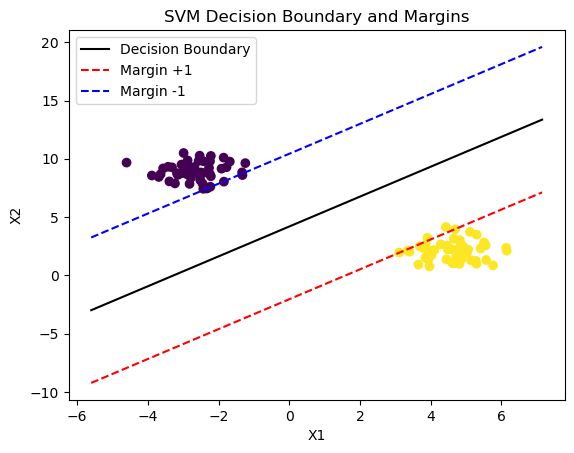

In [10]:
# Plot the dataset and the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.plot(x1_range, decision_boundary, 'k-', label='Decision Boundary')
plt.plot(x1_range, margin_positive, 'r--', label='Margin +1')
plt.plot(x1_range, margin_negative, 'b--', label='Margin -1')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM Decision Boundary and Margins")
plt.legend()
plt.show()

## Results and Analysis

The decision boundary correctly separates the two classes. However, the margin is
visibly asymmetric: the boundary is not centred between the two margin lines.

**Why the margin is asymmetric:**

Subgradient descent on the primal objective does not converge to the exact
maximum-margin solution. Two compounding effects cause the asymmetry here:

1. **Regularisation accumulation.** The update **w -= lr * w** is applied at every
   step, including correctly classified points. Over 5000 epochs × 100 points =
   500 000 steps, this shrinks **w** disproportionately relative to the hinge loss
   updates, biasing the boundary away from the true maximum-margin position.

2. **No stopping criterion.** A proper implementation would track the duality gap
   or monitor KKT violations to stop when the solution is close enough. Here the
   fixed number of epochs means the model may overshoot or undershoot.

**What a correct solution looks like:**

The true maximum-margin hyperplane satisfies $y_i(\mathbf{w}^\top \mathbf{x}_i + b) = 1$
for the support vectors of both classes simultaneously, placing the boundary
exactly equidistant from both margin lines. This is what **sklearn.SVC** produces
via SMO on the dual, verified in **project.ipynb**.

**Key takeaway:**

The primal subgradient approach is sufficient to build intuition for the hinge loss
and the role of $C$, but it is not the algorithm used in practice. The dual
formulation with SMO is both theoretically cleaner (direct access to support vectors
via $\alpha_i > 0$) and computationally more reliable.